# Present Value vs. Future Value
### Time Value of Money — Chapter 1

Every financial amount carries a value that depends on *when* it is received, not just *how much* it is. This is the core idea behind the **time value of money (TVM)**: a dollar today is generally worth more than a dollar in the future, because today's dollar can be invested and start earning a return immediately.

Two amounts that arrive at different points in time can only be compared once they are brought to the same point in time:
- **Present Value (PV)** — what a future amount is worth *today*
- **Future Value (FV)** — what a present amount will be worth *later*

## The Situation

Imagine a friend promises to pay you **\$1,000 in 365 days**. Would you rather receive the money today, or wait a full year to collect it?

Answering that question — and putting a precise number on *how much* today's dollar is worth compared to next year's — is exactly what present value and future value calculations let us do.

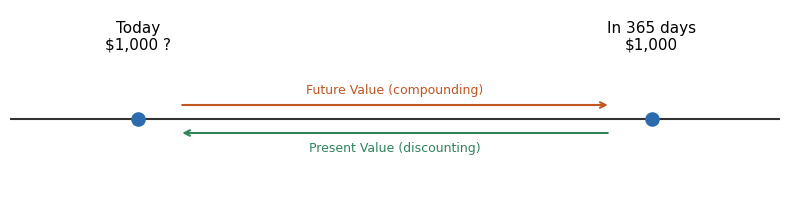

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2.2))

# Timeline
ax.axhline(0, color="#333333", linewidth=1.5, zorder=1)
ax.scatter([0, 1], [0, 0], s=90, color="#2b6cb0", zorder=3)

ax.annotate("Today\n$1,000 ?", xy=(0, 0), xytext=(0, 0.35),
            ha="center", fontsize=11)
ax.annotate("In 365 days\n$1,000", xy=(1, 0), xytext=(1, 0.35),
            ha="center", fontsize=11)

ax.annotate("", xy=(0.92, 0.07), xytext=(0.08, 0.07),
            arrowprops=dict(arrowstyle="->", color="#c05621", lw=1.5))
ax.text(0.5, 0.13, "Future Value (compounding)", ha="center",
        fontsize=9, color="#c05621")

ax.annotate("", xy=(0.08, -0.07), xytext=(0.92, -0.07),
            arrowprops=dict(arrowstyle="->", color="#2f855a", lw=1.5))
ax.text(0.5, -0.16, "Present Value (discounting)", ha="center",
        fontsize=9, color="#2f855a")

ax.set_xlim(-0.25, 1.25)
ax.set_ylim(-0.4, 0.55)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Exercise 1.1.A — Calculating Operating Cash Flow (OCF)
*Also known as Capacité d'Autofinancement (CAF) in French accounting.*

### Given
**Stranger Company** reports the following for the period:

| Item | Amount |
|---|---:|
| Sales Revenue | \$30,000 |
| Total Operating Expenses (incl. depreciation) | \$21,000 |
| &nbsp;&nbsp;&nbsp;&nbsp;of which Depreciation | \$3,000 |
| Interest Expense | \$1,000 |
| Tax Rate | 25% |

**Required:** Determine the company's Operating Cash Flow (OCF).

### Solution

**Step 1 — Split operating expenses from depreciation** (depreciation is a non-cash charge, so it's useful to isolate it):

$$\text{Operating Expenses (excl. depreciation)} = \$21{,}000 - \$3{,}000 = \$18{,}000$$

**Step 2 — Earnings Before Interest and Taxes (EBIT):**

$$EBIT = \text{Sales} - \text{Total Operating Expenses} = \$30{,}000 - \$21{,}000 = \$9{,}000$$

**Step 3 — Earnings Before Taxes (EBT):**

$$EBT = EBIT - \text{Interest} = \$9{,}000 - \$1{,}000 = \$8{,}000$$

**Step 4 — Taxes:**

$$\text{Taxes} = EBT \times \text{tax rate} = \$8{,}000 \times 25\% = \$2{,}000$$

**Step 5 — Net income:**

$$\text{Net Income} = EBT - \text{Taxes} = \$8{,}000 - \$2{,}000 = \$6{,}000$$

In [2]:
# Verifying the calculation programmatically
sales = 30_000
total_operating_expenses = 21_000
depreciation = 3_000
interest_expense = 1_000
tax_rate = 0.25

operating_expenses_excl_dep = total_operating_expenses - depreciation
EBIT = sales - total_operating_expenses
EBT = EBIT - interest_expense
taxes = EBT * tax_rate
net_income = EBT - taxes
ocf_addback = net_income + depreciation  # standard OCF/CAF: add depreciation back

print(f"{'Operating exp. (excl. depreciation)':38}: ${operating_expenses_excl_dep:>7,.0f}")
print(f"{'EBIT':38}: ${EBIT:>7,.0f}")
print(f"{'EBT':38}: ${EBT:>7,.0f}")
print(f"{'Taxes (25%)':38}: ${taxes:>7,.0f}")
print(f"{'Net Income (EBT - Taxes)':38}: ${net_income:>7,.0f}")
print(f"{'OCF (Net Income + Depreciation)':38}: ${ocf_addback:>7,.0f}")

Operating exp. (excl. depreciation)   : $ 18,000
EBIT                                  : $  9,000
EBT                                   : $  8,000
Taxes (25%)                           : $  2,000
Net Income (EBT - Taxes)              : $  6,000
OCF (Net Income + Depreciation)       : $  9,000


### Answer

$$\boxed{OCF = \$6{,}000}$$

> **Note — a convention to double-check with your course.** The \$6,000 above is EBT after taxes, i.e. **net income**. Depreciation is a *non-cash* charge, so the standard OCF / CAF formula adds it back: $OCF = \text{Net Income} + \text{Depreciation} = \$6{,}000 + \$3{,}000 = \$9{,}000$. Some courses also exclude interest from OCF entirely, since it's a financing cost rather than an operating one, which would give $EBIT \times (1-\text{tax}) + \text{Depreciation} = \$9{,}750$. Use whichever definition your instructor specified — the code cell above prints both the \$6,000 and \$9,000 versions so you can compare.